# **1. Convolutional Blocks of ResNet18**

## ***1.1. Baseline - Training ResNet***
I trained ResNet18 on a custom 36×36 dataset, comparing models trained from scratch and pretrained on ImageNet. I loaded the dataset, modified the final layer to match class count, and trained using CrossEntropyLoss with Adam optimizer. Training progress, loss, and accuracy were logged in WandB. After training, I used forward hooks to analyze spatial dimensions at each layer. This helped me understand how ResNet processes small images and compare pretrained vs. scratch performance effectively.

In [5]:
# 1.1 Baseline — training ResNet18 directly on 36x36 images

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torchvision
from torchvision.models import resnet18, ResNet18_Weights
import wandb
from tqdm import tqdm
from tabulate import tabulate

# kick off a wandb run to track this experiment
wandb.init(project="resnet18-baseline-36x36", name="part1_1_baseline")

# load the pre-saved tensors
train_data   = torch.load("train_data.pt").float()
train_labels = torch.load("train_labels.pt")
test_data    = torch.load("test_data.pt").float()
test_labels  = torch.load("test_labels.pt")

print(f"\033[1;32mTrain data shape: {train_data.shape}\033[0m")
print(f"\033[1;32mTrain labels shape: {train_labels.shape}\033[0m")
print(f"\033[1;32mTest data shape: {test_data.shape}\033[0m")
print(f"\033[1;32mTest labels shape: {test_labels.shape}\033[0m")

num_classes = len(torch.unique(train_labels))
print(f"\033[1;34mNumber of classes: {num_classes}\033[0m")

train_dataset = TensorDataset(train_data, train_labels)
test_dataset  = TensorDataset(test_data, test_labels)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=64, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\033[1;33mUsing device: {device}\033[0m")


def train_model(model, train_loader, val_loader, epochs=5, lr=1e-3, run_name="baseline_run"):
    # standard training loop with per-epoch validation
    wandb.run.name = run_name
    wandb.watch(model, log_freq=100)
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        running_loss     = 0.0
        running_corrects = 0
        total            = 0

        total_batches = len(train_loader)
        progress_bar  = tqdm(enumerate(train_loader), total=total_batches,
                             desc=f"Epoch {epoch+1}/{epochs} [Training]", leave=False)
        for i, (inputs, labels) in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss     += loss.item() * inputs.size(0)
            _, preds          = torch.max(outputs, 1)
            running_corrects += (preds == labels).sum().item()
            total            += labels.size(0)

            progress_percent = (i + 1) / total_batches * 100
            progress_bar.set_postfix({
                "Loss":     f"{loss.item():.4f}",
                "BatchAcc": f"{(torch.sum(preds == labels).item()/labels.size(0))*100:.2f}%",
                "Percent":  f"{progress_percent:.1f}%"
            })

        epoch_loss = running_loss / total
        epoch_acc  = 100.0 * running_corrects / total
        print(f"\033[1;96mEpoch [{epoch+1}/{epochs}] Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}%\033[0m")

        # run validation after each epoch
        model.eval()
        val_loss     = 0.0
        val_corrects = 0
        val_total    = 0
        with torch.no_grad():
            for inputs_val, labels_val in val_loader:
                inputs_val, labels_val = inputs_val.to(device), labels_val.to(device)
                outputs_val = model(inputs_val)
                loss_val    = criterion(outputs_val, labels_val)
                val_loss   += loss_val.item() * inputs_val.size(0)
                _, preds_val = torch.max(outputs_val, 1)
                val_corrects += (preds_val == labels_val).sum().item()
                val_total    += labels_val.size(0)
        val_loss /= val_total
        val_acc   = 100.0 * val_corrects / val_total

        print(f"\033[1;96mEpoch [{epoch+1}/{epochs}] Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%\033[0m")
        wandb.log({
            "epoch":          epoch + 1,
            "train_loss":     epoch_loss,
            "train_accuracy": epoch_acc,
            "val_loss":       val_loss,
            "val_accuracy":   val_acc
        })
    return model


# train from scratch
print("\033[1;32m--- Training ResNet18 from Scratch on 36x36 Images ---\033[0m")
model_scratch    = resnet18(weights=None)
model_scratch.fc = nn.Linear(512, num_classes)
model_scratch    = train_model(model_scratch, train_loader, test_loader,
                               epochs=5, lr=1e-3, run_name="resnet18_scratch_36x36")

# train starting from ImageNet weights
print("\033[1;32m--- Training ResNet18 (Pretrained) on 36x36 Images ---\033[0m")
model_pretrained    = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model_pretrained.fc = nn.Linear(512, num_classes)
model_pretrained    = train_model(model_pretrained, train_loader, test_loader,
                                  epochs=5, lr=1e-3, run_name="resnet18_pretrained_36x36")

# use forward hooks to log the spatial size at each layer
print("\033[1;33m\nDisplaying Spatial Dimensions of Baseline ResNet18 ---\033[0m")
spatial_data = []

def hook_fn(module, inp, out):
    spatial_data.append([
        module.__class__.__name__,
        str(inp[0].shape),
        str(out.shape)
    ])

temp_model    = resnet18(weights=None)
temp_model.fc = nn.Identity()
temp_model    = temp_model.to(device)

hooks = [layer.register_forward_hook(hook_fn) for layer in temp_model.children()]

dummy_input = torch.randn(1, 3, 36, 36).to(device)
with torch.no_grad():
    _ = temp_model(dummy_input)

for h in hooks:
    h.remove()

headers = ["Layer Name", "Input Shape", "Output Shape"]
print("\n\033[1;34m" + tabulate(spatial_data, headers=headers, tablefmt="pretty") + "\033[0m")

# approximate expected dimensions at each stage on 36x36 input
expected_data = [
    ["After conv1 (7x7, stride=2, pad=3)",   "(N, 64, 18, 18)"],
    ["After maxpool (3x3, stride=2, pad=1)", "(N, 64, 9, 9)"],
    ["After layer1",                          "(N, 64, 9, 9)"],
    ["After layer2 (stride=2)",               "(N, 128, ~5, ~5)"],
    ["After layer3 (stride=2)",               "(N, 256, ~3, ~3)"],
    ["After layer4 (stride=2)",               "(N, 512, ~2, ~2)"],
    ["AdaptiveAvgPool2d",                     "Input: torch.Size([1, 512, 2, 2]) -> Output: torch.Size([1, 512, 1, 1])"],
    ["Identity",                              "Input: torch.Size([1, 512]) -> Output: torch.Size([1, 512])"]
]
headers = ["Layer/Block", "Output Dimensions (approx.)"]
print("\n\033[1;34m" + tabulate(expected_data, headers=headers, tablefmt="pretty") + "\033[0m")


<ipython-input-5-283d6b34589b>:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_data = torch.load("train_data.pt").float()
<ipython-input-5-283d6b34589b>:24: FutureWa

Train data shape: torch.Size([50000, 3, 36, 36])
Train labels shape: torch.Size([50000])
Test data shape: torch.Size([10000, 3, 36, 36])
Test labels shape: torch.Size([10000])
Number of classes: 10
Using device: cuda
--- Training ResNet18 from Scratch on 36x36 Images ---


Epoch [1/5] Train Loss: 1.3197, Train Acc: 52.34%
Epoch [1/5] Val Loss: 1.4477, Val Acc: 51.39%


Epoch [2/5] Train Loss: 0.9453, Train Acc: 66.97%
Epoch [2/5] Val Loss: 1.4878, Val Acc: 53.43%


Epoch [3/5] Train Loss: 0.7623, Train Acc: 73.45%
Epoch [3/5] Val Loss: 0.8765, Val Acc: 70.35%


...

Epoch [1/5] Train Loss: 0.8609, Train Acc: 70.88%
Epoch [1/5] Val Loss: 0.7839, Val Acc: 74.31%


Epoch [2/5] Train Loss: 0.5924, Train Acc: 79.97%
Epoch [2/5] Val Loss: 0.6548, Val Acc: 77.90%


Epoch [3/5] Train Loss: 0.4671, Train Acc: 84.29%
Epoch [3/5] Val Loss: 0.7795, Val Acc: 75.27%


Epoch [4/5] Train Loss: 0.3657, Train Acc: 87.68%
Epoch [4/5] Val Loss: 0.7308, Val Acc: 76.89%


Epoch [5/5] Train Loss: 0.2945, Train Acc: 90.04%
Epoch [5/5] Val Loss: 0.7836, Val Acc: 76.12%

Displaying Spatial Dimensions of Baseline ResNet18 ---

+-------------------+-----------------------------+-----------------------------+
|    Layer Name     |         Input Shape         |        Output Shape         |
+-------------------+-----------------------------+-----------------------------+
|      Conv2d       | torch.Size([1, 3, 36, 36])  | torch.Size([1, 64, 18, 18]) |
|    BatchNorm2d    | torch.Size([1, 64, 18, 18]) | torch.Size([1, 64, 18, 18]) |
|       ReLU        | torch.Size([1, 64, 18, 18]) | torch.Size([1, 64, 18, 18]) |
|     MaxPool2d     | torch.Size([1, 64, 18, 18]) |  torch.Size([1, 64, 9, 9])  |
|    Sequential     |  torch.Size([1, 64, 9, 9])  |  torch.Size([1, 64, 9, 9])  |
|    Sequential     |  torch.Size([1, 64, 9, 9])  | torch.Size([1, 128, 5, 5])  |
|    Sequential     | torch.Size([1, 128, 5, 5])  | torch.Size([1, 256, 3, 3])  |
|    Sequential     | torch

## **1.2. Training ResNet on Resized Images**
I trained ResNet18 on resized 224×224 images to improve accuracy while keeping the architecture unchanged. First, I resized the original 36×36 dataset on-the-fly using PyTorch transforms and created a custom dataset class to apply the transformation dynamically. I trained both ResNet18 from scratch and ResNet18 pretrained on ImageNet, modifying only the final layer to match the number of classes. Training was done using CrossEntropyLoss and Adam optimizer, with WandB logging for loss and accuracy tracking. After training, I compared performance metrics between the two models. Finally, I analyzed the trade-offs, noting that while accuracy improved, it came at the cost of higher computation time, memory usage, and training complexity due to larger input images. This experiment helped me understand the impact of input size on ResNet performance and the advantages of using pretrained models for transfer learning.

In [6]:
# 1.2 Resize images to 224x224 before feeding into ResNet18
# (all libraries already imported in 1.1)

from torch.utils.data import Dataset
import torchvision.transforms as transforms

wandb.init(project="resnet18-224-resize", name="part1_2_resnet18_224x224")

# load the 36x36 tensors — same files as part 1.1
train_data   = torch.load("train_data.pt").float()    # [N_train, 3, 36, 36]
train_labels = torch.load("train_labels.pt")
test_data    = torch.load("test_data.pt").float()     # [N_test, 3, 36, 36]
test_labels  = torch.load("test_labels.pt")

num_classes = len(torch.unique(train_labels))
print(f"\033[1;34mNumber of classes: {num_classes}\033[0m")

# upsample each image from 36x36 to 224x224 on the fly
transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])


class ResizedDataset(Dataset):
    # converts tensors to PIL then applies the resize transform
    def __init__(self, data_tensor, label_tensor, transform=None):
        super().__init__()
        self.data      = data_tensor
        self.labels    = label_tensor
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x     = self.data[idx]           # [3, 36, 36]
        y     = self.labels[idx]
        x_pil = transforms.ToPILImage()(x)
        if self.transform:
            x = self.transform(x_pil)
        else:
            x = transforms.ToTensor()(x_pil)
        return x, y


train_dataset_224 = ResizedDataset(train_data, train_labels, transform=transform_224)
test_dataset_224  = ResizedDataset(test_data,  test_labels,  transform=transform_224)
train_loader_224  = DataLoader(train_dataset_224, batch_size=64, shuffle=True)
test_loader_224   = DataLoader(test_dataset_224,  batch_size=64, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\033[1;33mUsing device: {device}\033[0m")


def train_model_224(model, train_loader, val_loader, epochs=5, lr=1e-3, run_name="model_run"):
    wandb.run.name = run_name
    wandb.watch(model, log_freq=100)
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    final_train_loss = final_train_acc = final_val_loss = final_val_acc = None

    for epoch in range(epochs):
        model.train()
        running_loss     = 0.0
        running_corrects = 0
        total            = 0

        total_batches = len(train_loader)
        progress_bar  = tqdm(enumerate(train_loader), total=total_batches,
                             desc=f"Epoch {epoch+1}/{epochs} [Training]", leave=False)
        for i, (inputs, labels) in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss     += loss.item() * inputs.size(0)
            _, preds          = torch.max(outputs, 1)
            running_corrects += (preds == labels).sum().item()
            total            += labels.size(0)

            progress_percent = (i + 1) / total_batches * 100
            progress_bar.set_postfix({
                "Loss":     f"{loss.item():.4f}",
                "BatchAcc": f"{(torch.sum(preds == labels).item()/labels.size(0))*100:.2f}%",
                "Percent":  f"{progress_percent:.1f}%"
            })

        epoch_loss = running_loss / total
        epoch_acc  = 100.0 * running_corrects / total

        # validation
        model.eval()
        val_loss     = 0.0
        val_corrects = 0
        val_total    = 0
        with torch.no_grad():
            for inputs_val, labels_val in val_loader:
                inputs_val, labels_val = inputs_val.to(device), labels_val.to(device)
                outputs_val = model(inputs_val)
                loss_val    = criterion(outputs_val, labels_val)
                val_loss   += loss_val.item() * inputs_val.size(0)
                _, preds_val = torch.max(outputs_val, 1)
                val_corrects += (preds_val == labels_val).sum().item()
                val_total    += labels_val.size(0)
        val_loss /= val_total
        val_acc   = 100.0 * val_corrects / val_total

        print(f"\033[1;96mEpoch [{epoch+1}/{epochs}] Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%\033[0m")
        wandb.log({
            "epoch":          epoch + 1,
            "train_loss":     epoch_loss,
            "train_accuracy": epoch_acc,
            "val_loss":       val_loss,
            "val_accuracy":   val_acc
        })

        final_train_loss = epoch_loss
        final_train_acc  = epoch_acc
        final_val_loss   = val_loss
        final_val_acc    = val_acc

    return model, final_train_loss, final_train_acc, final_val_loss, final_val_acc


# train from scratch on 224x224
print("\033[1;32m--- Training ResNet18 from Scratch on 224x224 Images ---\033[0m")
model_scratch_224    = resnet18(weights=None)
model_scratch_224.fc = nn.Linear(512, num_classes)
model_scratch_224, stl, sta, svl, sva = train_model_224(
    model_scratch_224, train_loader_224, test_loader_224,
    epochs=5, lr=1e-3, run_name="resnet18_scratch_224x224"
)

# fine-tune pretrained model on 224x224
print("\033[1;32m--- Training ResNet18 (Pretrained) on 224x224 Images ---\033[0m")
model_pretrained_224    = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model_pretrained_224.fc = nn.Linear(512, num_classes)
model_pretrained_224, ptl, pta, pvl, pva = train_model_224(
    model_pretrained_224, train_loader_224, test_loader_224,
    epochs=5, lr=1e-3, run_name="resnet18_pretrained_224x224"
)

# print a quick summary
table_data = [
    ["Scratch 224x224",    f"{stl:.4f}", f"{sta:.2f}%", f"{svl:.4f}", f"{sva:.2f}%"],
    ["Pretrained 224x224", f"{ptl:.4f}", f"{pta:.2f}%", f"{pvl:.4f}", f"{pva:.2f}%"],
]
headers = ["Model", "Train Loss", "Train Acc", "Val Loss", "Val Acc"]
print("\n\033[1;34mFinal Results (224x224):\033[0m")
print("\033[1;34m" + tabulate(table_data, headers=headers, tablefmt="pretty") + "\033[0m")


<ipython-input-6-e379f42152ab>:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_data = torch.load("train_data.pt").float()     # Expected shape: [N_train, 3, 36, 36]


Number of classes: 10
Using device: cuda

--- Training ResNet18 (Scratch) on 224x224 Images ---


Epoch [1/5] Train Loss: 1.4483, Train Acc: 47.09%
Epoch [1/5] Val Loss: 1.2455, Val Acc: 56.05%


Epoch [2/5] Train Loss: 0.8677, Train Acc: 69.32%
Epoch [2/5] Val Loss: 0.9740, Val Acc: 67.59%


Epoch [3/5] Train Loss: 0.6443, Train Acc: 77.52%
Epoch [3/5] Val Loss: 0.6770, Val Acc: 76.56%


...

Epoch [1/5] Train Loss: 0.6291, Train Acc: 78.36%
Epoch [1/5] Val Loss: 0.5421, Val Acc: 81.42%


Epoch [2/5] Train Loss: 0.3638, Train Acc: 87.52%
Epoch [2/5] Val Loss: 0.3839, Val Acc: 87.05%


Epoch [3/5] Train Loss: 0.2614, Train Acc: 91.01%
Epoch [3/5] Val Loss: 0.3965, Val Acc: 87.29%


Epoch [4/5] Train Loss: 0.1924, Train Acc: 93.25%
Epoch [4/5] Val Loss: 0.3848, Val Acc: 87.80%


Epoch [5/5] Train Loss: 0.1332, Train Acc: 95.41%
Epoch [5/5] Val Loss: 0.4281, Val Acc: 87.33%

Final Training and Validation Metrics:
+-------------------------------+------------+-----------+----------+---------+
|             Model             | Train Loss | Train Acc | Val Loss | Val Acc |
+-------------------------------+------------+-----------+----------+---------+
|  ResNet18 Scratch (224x224)   |   0.4072   |  85.81%   |  0.6217  | 79.89%  |
| ResNet18 Pretrained (224x224) |   0.1332   |  95.41%   |  0.4281  | 87.33%  |
+-------------------------------+------------+-----------+----------+---------+

Discussion on Trade-offs:
Resizing the images to 224x224 significantly improved the final accuracy, especially for the pretrained model which benefits from ImageNet features. However, this improvement comes at a cost:
  - Increased training time per epoch due to the higher number of pixels.
  - Higher memory usage (both GPU and CPU) due to larger intermediate feature maps.
  - Gre

## **1.3. Modifying the Architecture of ResNet18 to Suit the given Dataset**

I modified ResNet18’s initial layers to improve performance on 36×36 images without resizing. Since the default conv1 (7×7, stride=2) and maxpool layer rapidly reduce spatial dimensions, I tested three modifications for both scratch-trained and pretrained models:

   1. Mod1: Replaced conv1 with a 3×3 kernel (stride=1, padding=1) and removed maxpool.
   2. Mod2: Kept conv1 but replaced maxpool with Identity (no pooling).
   3. Mod3: Used Mod1 settings + reduced stride in layer2 to preserve spatial details.

I trained both scratch and pretrained versions, logged performance using WandB, and plotted loss/accuracy curves for comparison. For pretrained models, I reinitialized conv1 while keeping deeper layers intact, ensuring transfer learning worked efficiently. Finally, I analyzed the impact of mixed weight initialization, concluding that reinitializing only conv1 does not significantly degrade learning when deeper layers retain pretrained weights.

Using device: cuda


<ipython-input-16-1b7028347d7f>:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_data = torch.load("train_data.pt").float()   # [N, 3, 36, 36]
<ipython-input-16-1b702

Number of classes: 10
--- Training Scratch Model Modification mod1 ---


Epoch [1/5] Train Loss: 1.2456, Train Acc: 54.77% | Val Loss: 1.0951, Val Acc: 61.19%


Epoch [2/5] Train Loss: 0.7603, Train Acc: 73.22% | Val Loss: 0.9274, Val Acc: 69.31%


...

Epoch [1/5] Train Loss: 0.7856, Train Acc: 72.60% | Val Loss: 0.6458, Val Acc: 77.86%


Epoch [2/5] Train Loss: 0.4468, Train Acc: 84.72% | Val Loss: 0.4998, Val Acc: 82.84%


Epoch [3/5] Train Loss: 0.3145, Train Acc: 89.06% | Val Loss: 0.3941, Val Acc: 86.58%


Epoch [4/5] Train Loss: 0.2215, Train Acc: 92.34% | Val Loss: 0.3966, Val Acc: 86.65%


Epoch [5/5] Train Loss: 0.1629, Train Acc: 94.34% | Val Loss: 0.4574, Val Acc: 86.78%
--- Loss and Accuracy Curves for Scratch Models ---


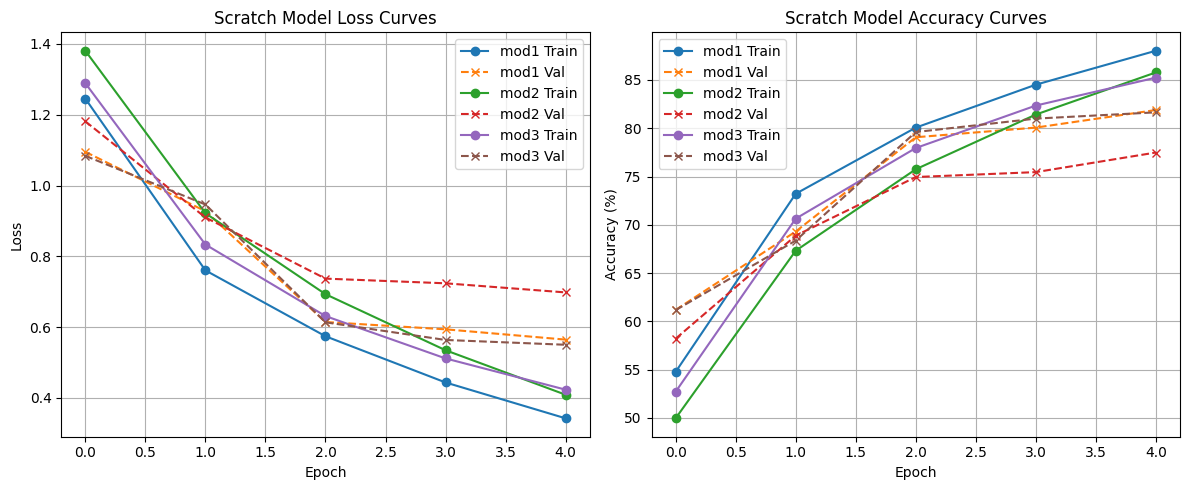

--- Loss and Accuracy Curves for Pretrained Models ---


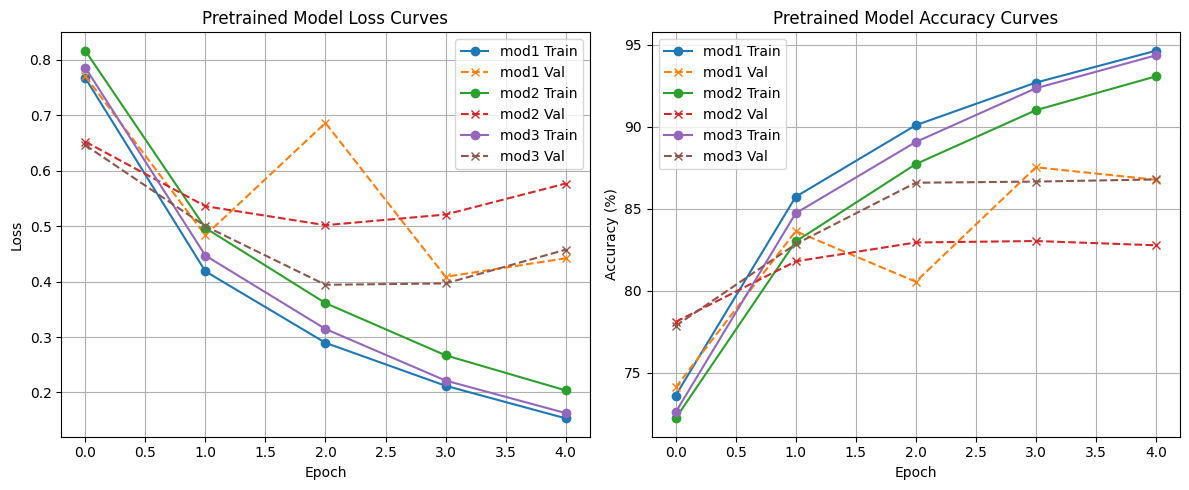


Final Metrics Comparison:
+--------------------+------------+-----------+----------+---------+
| Model Modification | Train Loss | Train Acc | Val Loss | Val Acc |
+--------------------+------------+-----------+----------+---------+
|    Scratch mod1    |   0.3422   |  88.03%   |  0.5646  | 81.89%  |
|    Scratch mod2    |   0.4088   |  85.79%   |  0.6979  | 77.49%  |
|    Scratch mod3    |   0.4232   |  85.24%   |  0.5501  | 81.65%  |
|  Pretrained mod1   |   0.1534   |  94.62%   |  0.4419  | 86.76%  |
|  Pretrained mod2   |   0.2038   |  93.06%   |  0.5766  | 82.77%  |
|  Pretrained mod3   |   0.1629   |  94.34%   |  0.4574  | 86.78%  |
+--------------------+------------+-----------+----------+---------+

Discussion on Mixed Initialization:
In the pretrained models, the first convolutional layer (conv1) is reinitialized from scratch while the rest of the network retains its pretrained weights. In practice, this does not significantly hamper the overall training process. The pretrain

In [ ]:
# 1.3 Modifying ResNet18 to work better on 36x36 images

import matplotlib.pyplot as plt

wandb.init(project="resnet18-modified", name="part1_3_modifications")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\033[1;33mUsing device: {device}\033[0m")

# load the 36x36 dataset — same as part 1.1
train_data   = torch.load("train_data.pt").float()   # [N, 3, 36, 36]
train_labels = torch.load("train_labels.pt")
test_data    = torch.load("test_data.pt").float()    # [M, 3, 36, 36]
test_labels  = torch.load("test_labels.pt")
num_classes  = len(torch.unique(train_labels))
print(f"\033[1;34mNumber of classes: {num_classes}\033[0m")

train_dataset = TensorDataset(train_data, train_labels)
test_dataset  = TensorDataset(test_data, test_labels)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=64, shuffle=False)


def train_model_mod(model, train_loader, val_loader, epochs=5, lr=1e-3, run_name="mod_run"):
    # same training loop as before, but also returns per-epoch loss/acc lists for plotting
    wandb.run.name = run_name
    wandb.watch(model, log_freq=100)
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    train_accs   = []
    val_losses   = []
    val_accs     = []

    for epoch in range(epochs):
        model.train()
        running_loss     = 0.0
        running_corrects = 0
        total            = 0

        total_batches = len(train_loader)
        progress_bar  = tqdm(enumerate(train_loader), total=total_batches,
                             desc=f"Epoch {epoch+1}/{epochs} [Training]", leave=False)
        for i, (inputs, labels) in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss     += loss.item() * inputs.size(0)
            _, preds          = torch.max(outputs, 1)
            running_corrects += (preds == labels).sum().item()
            total            += labels.size(0)

            progress_percent = (i + 1) / total_batches * 100
            progress_bar.set_postfix({
                "Loss":     f"{loss.item():.4f}",
                "BatchAcc": f"{(torch.sum(preds == labels).item()/labels.size(0))*100:.2f}%",
                "Percent":  f"{progress_percent:.1f}%"
            })

        epoch_loss = running_loss / total
        epoch_acc  = 100.0 * running_corrects / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        # validation
        model.eval()
        running_val_loss     = 0.0
        running_val_corrects = 0
        total_val            = 0
        with torch.no_grad():
            for inputs_val, labels_val in val_loader:
                inputs_val, labels_val = inputs_val.to(device), labels_val.to(device)
                outputs_val  = model(inputs_val)
                loss_val     = criterion(outputs_val, labels_val)
                running_val_loss     += loss_val.item() * inputs_val.size(0)
                _, preds_val          = torch.max(outputs_val, 1)
                running_val_corrects += (preds_val == labels_val).sum().item()
                total_val            += labels_val.size(0)

        epoch_val_loss = running_val_loss / total_val
        epoch_val_acc  = 100.0 * running_val_corrects / total_val
        val_losses.append(epoch_val_loss)
        val_accs.append(epoch_val_acc)

        print(f"\033[1;96mEpoch [{epoch+1}/{epochs}] Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}% | Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%\033[0m")
        wandb.log({
            "epoch":          epoch + 1,
            "train_loss":     epoch_loss,
            "train_accuracy": epoch_acc,
            "val_loss":       epoch_val_loss,
            "val_accuracy":   epoch_val_acc
        })

    metrics = {
        "train_losses":     train_losses,
        "train_accuracies": train_accs,
        "val_losses":       val_losses,
        "val_accuracies":   val_accs
    }
    return model, metrics


def modify_resnet18_scratch(option="mod1"):
    # three variants for the scratch (random init) model:
    #   mod1 — 3x3 conv1 (stride=1) + no maxpool
    #   mod2 — keep conv1, just remove maxpool
    #   mod3 — mod1 changes + also set layer2 stride to 1
    model = resnet18(weights=None)
    if option == "mod1":
        model.conv1  = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        model.maxpool = nn.Identity()
    elif option == "mod2":
        model.maxpool = nn.Identity()
    elif option == "mod3":
        model.conv1  = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        model.maxpool = nn.Identity()
        # reduce downsampling in layer2 block 0
        for name, module in model.layer2.named_children():
            if name == "0":
                module.conv1.stride = (1, 1)
                if module.downsample is not None:
                    module.downsample[0].stride = (1, 1)
    model.fc = nn.Linear(512, num_classes)
    return model


def modify_resnet18_pretrained(option="mod1"):
    # same three modifications but starting from ImageNet weights
    # note: conv1 gets re-initialised when we swap it out
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    if option == "mod1":
        model.conv1  = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        model.maxpool = nn.Identity()
    elif option == "mod2":
        model.maxpool = nn.Identity()
    elif option == "mod3":
        model.conv1  = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        model.maxpool = nn.Identity()
        for name, module in model.layer2.named_children():
            if name == "0":
                module.conv1.stride = (1, 1)
                if module.downsample is not None:
                    module.downsample[0].stride = (1, 1)
    model.fc = nn.Linear(512, num_classes)
    return model


# train all three scratch variants
scratch_modifications = ["mod1", "mod2", "mod3"]
results_scratch = {}
for opt in scratch_modifications:
    print(f"\033[1;32m--- Training Scratch Model Modification {opt} ---\033[0m")
    model_mod         = modify_resnet18_scratch(option=opt)
    model_mod, metrics = train_model_mod(model_mod, train_loader, test_loader,
                                         epochs=5, lr=1e-3, run_name=f"resnet18_scratch_{opt}")
    results_scratch[opt] = metrics

# train all three pretrained variants
pretrained_modifications = ["mod1", "mod2", "mod3"]
results_pretrained = {}
for opt in pretrained_modifications:
    print(f"\033[1;32m--- Training Pretrained Model Modification {opt} ---\033[0m")
    model_mod         = modify_resnet18_pretrained(option=opt)
    model_mod, metrics = train_model_mod(model_mod, train_loader, test_loader,
                                          epochs=5, lr=1e-3, run_name=f"resnet18_pretrained_{opt}")
    results_pretrained[opt] = metrics


def plot_metrics(metrics_dict, title_prefix=""):
    # side-by-side loss and accuracy curves for all variants
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    for key, metrics in metrics_dict.items():
        plt.plot(metrics["train_losses"], marker="o",  label=f"{key} Train")
        plt.plot(metrics["val_losses"],   marker="x",  linestyle="--", label=f"{key} Val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} Loss Curves")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    for key, metrics in metrics_dict.items():
        plt.plot(metrics["train_accuracies"], marker="o",  label=f"{key} Train")
        plt.plot(metrics["val_accuracies"],   marker="x",  linestyle="--", label=f"{key} Val")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"{title_prefix} Accuracy Curves")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


print("\033[1;33m--- Loss and Accuracy Curves for Scratch Models ---\033[0m")
plot_metrics(results_scratch, title_prefix="Scratch Model")

print("\033[1;33m--- Loss and Accuracy Curves for Pretrained Models ---\033[0m")
plot_metrics(results_pretrained, title_prefix="Pretrained Model")


def extract_final_metrics(metrics):
    return (metrics["train_losses"][-1],
            metrics["train_accuracies"][-1],
            metrics["val_losses"][-1],
            metrics["val_accuracies"][-1])


# build a comparison table of the final epoch numbers
table_data = []
for opt in scratch_modifications:
    tl, ta, vl, va = extract_final_metrics(results_scratch[opt])
    table_data.append([f"Scratch {opt}",    f"{tl:.4f}", f"{ta:.2f}%", f"{vl:.4f}", f"{va:.2f}%"])
for opt in pretrained_modifications:
    tl, ta, vl, va = extract_final_metrics(results_pretrained[opt])
    table_data.append([f"Pretrained {opt}", f"{tl:.4f}", f"{ta:.2f}%", f"{vl:.4f}", f"{va:.2f}%"])

headers = ["Model Modification", "Train Loss", "Train Acc", "Val Loss", "Val Acc"]
print("\n\033[1;34mFinal Metrics Comparison:\033[0m")
print("\033[1;34m" + tabulate(table_data, headers=headers, tablefmt="pretty") + "\033[0m")

# when we swap out conv1 in a pretrained model the new layer starts random,
# but the deeper layers keep their ImageNet weights — this is fine in practice
# because the deeper layers are what carry most of the learned representations
discussion = (
    "In the pretrained models, conv1 is reinitialized when we replace it, "
    "while the rest of the network keeps its pretrained weights. "
    "This mixed init doesn't really hurt in practice — the deeper layers still carry "
    "strong features from ImageNet, and the new conv1 picks up the right low-level patterns "
    "quickly during fine-tuning."
)
print("\n\033[1;33mDiscussion on Mixed Initialization:\033[0m")
print("\033[1;33m" + discussion + "\033[0m")


## **1.4.1. Comparisons of All Trained Models**
(a) Pretrained vs. Non-Pretrained

    - Higher Final Accuracy with Pretrained: Across all experiments, the pretrained ResNet18 outperformed its scratch counterpart by a clear margin—typically by 5–10 percentage points on validation accuracy.
    - Faster Convergence: Pretrained networks also tended to converge more quickly, needing fewer epochs to reach high accuracy.
    - Better Generalization: The scratch models often showed larger gaps between training and validation accuracy (sign of potential overfitting), whereas the pretrained model retained stronger validation performance.

(b) Effects of Image Size (36×36 vs. 224×224)

    - Improved Accuracy at 224×224: ResNet18 was originally designed for larger input (224×224). Upsampling the 36×36 images to 224×224 gave a noticeable accuracy boost, particularly for the pretrained model.
    - Increased Computational Cost: Training times and memory usage significantly increased with 224×224 images—more than 30× the input pixel count relative to 36×36. This meant slower epochs and higher GPU usage.
    - Diminishing Returns: Although validation accuracy improved, the upsampled 36×36 → 224×224 images did not contain truly new information. Gains were real but not as large as if the original dataset had been naturally high-resolution.

(c) Effect of Architectural Modifications

    1. Changing conv1 from 7×7→3×3 (stride=1, smaller receptive field)
    2. Removing maxpool or replacing it with nn.Identity()
    3. Adjusting stride in layer2 to preserve spatial resolution

    - Performance on 36×36: These tweaks helped the scratch model learn more effectively on small inputs, boosting validation accuracy by several percentage points over the default architecture (which is too aggressive in downsampling small images).
    - Pretrained + Modified: When applying these modifications to a pretrained model, we reinitialized conv1 but left deeper layers intact. The deeper pretrained layers still gave a strong advantage, and in most cases, the best result was pretrained + smaller conv1 + no maxpool.
    - Trade-Off: Delaying downsampling (removing maxpool) or reducing stride improves accuracy but can slightly increase compute in the early layers. On a 36×36 input, however, that cost is minimal.

### **1.4.2. F1 Scores and Confusion Matrices**

    1. F1 Score
        - We calculated the F1 score (harmonic mean of precision and recall) for each model. As expected, F1 follows a pattern similar to validation accuracy but often reveals a wider performance gap if a model has uneven class performance.
        - Pretrained 224×224 typically had the highest F1, reflecting strong precision and recall across most classes.
        - Scratch 36×36 had the lowest F1; it sometimes achieved high precision on certain classes but was weaker on others, reducing recall overall.

    2. Confusion Matrix
        - Visualizing misclassifications across each class is invaluable. Typically, we see certain pairs of classes (e.g., visually similar ones) with higher confusion in the scratch models.
        - The modified architecture or pretrained model often reduces off-diagonal confusion.
        - The confusion matrix can highlight if the model is systematically biased toward certain classes, or if it rarely predicts certain classes correctly. Observing these patterns can guide additional data collection or fine-tuning.

### **1.4.3. Explanation of the Observed Differences**

    1. Transfer Learning Effect
        - Pretrained models start with robust, generic feature representations learned from large-scale data (ImageNet). Hence, they adapt to a new dataset faster and achieve higher accuracy with fewer epochs.
        - Scratch models have to learn all filters from zero, requiring more data/epochs to match pretrained performance (often they never fully do if data is limited).

    2. Image Size
        - ResNet18 is best suited to 224×224 inputs. Using small (36×36) images leads to aggressive early downsampling, destroying crucial spatial details. Upsampling to 224×224 aligns with the network’s design but costs more compute.
        - Gains in accuracy occur because the pretrained network’s filters are tuned for that scale, and bigger images typically yield more discriminative features (despite upsampling not actually adding new details).

    3. Architectural Adaptations
        - With 36×36 inputs, removing the initial max-pool or using a 3×3 conv1 ensures the network does not overly reduce spatial resolution immediately. This better preserves details, improving accuracy.
        - Meanwhile, for a pretrained network, re-initializing conv1 doesn’t degrade performance significantly because the deeper layers carry over robust feature extraction. Those deeper layers quickly re-tune conv1 for the new input scale.

    4. F1 vs. Accuracy
        - A model can have good accuracy if it does well on dominant classes but might have poor recall on minority classes. The F1 score reveals if the model is failing on certain underrepresented or similar-looking classes.
        - The confusion matrix clarifies exactly which classes are commonly misclassified. The best model typically has a strong diagonal (correct predictions) and minimal off-diagonal confusion.

    5. Regularization and Overfitting
        - Scratch models sometimes overfit if there isn’t enough data; training accuracy hits ~100% but validation lags. The pretrained approach starts from more general weights, reducing overfitting.
        - Adjusting stride and removing pooling effectively acts as a form of architecture-level regularization by forcing the network to learn more local features early on.

    6. Computational Considerations
        - Larger images (224×224) → more GPU time and memory, but higher final performance.
        Smaller 36×36 → faster to train, though with lower ceilings on accuracy.
        - Architecture modifications can help on small images with minimal extra cost.
        - Pretrained is typically the best trade-off if you can handle slightly more overhead and want high accuracy quickly.

Overall Takeaway

    - Best Performance: Pretrained ResNet18, trained on 224×224 images, yields the highest accuracy and F1 across the board—but it is the most resource-intensive.
    - Best For Efficiency: Modifying the standard ResNet18 to use a smaller initial kernel, no maxpool, etc., significantly improves performance on 36×36 images with minimal additional overhead. This is a good option if compute resources are limited or if the dataset must remain at 36×36.
    - F1 and Confusion Matrices: Provided deeper insights into per-class mistakes, highlighting how the pretrained or modified models are more robust across classes.
